<a href="https://colab.research.google.com/github/NamithaRStat/Assessment1_ICT/blob/main/ICT_EXIT_EXAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# libraries

In [ ]:
!pip install wordcloud

In [94]:
import numpy as np
import pandas as pd # fro dealing with dataframes
# for plotting
import matplotlib.pyplot as plt
import seaborn as sns
# for splitting the data
from sklearn.model_selection import train_test_split
#for word cloud

from wordcloud import WordCloud
# for counting  word cloud
from collections import Counter

import string
# for stopword management
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# for lemmatization
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.stem import PorterStemmer, WordNetLemmatizer

import tensorflow as tf
# for tokenisation
from tensorflow.keras.preprocessing.text import Tokenizer

# for ifidf embedding
from sklearn.feature_extraction.text import TfidfVectorizer

# for modeling
# ImportING classification algorithms
## LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression
# SVM classification
from sklearn.svm import LinearSVC
# random forest
from sklearn.ensemble import RandomForestClassifier

# for cross validation
from sklearn.model_selection import cross_val_score

# for evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
## for roc-auc
from sklearn.metrics import roc_curve, auc, roc_auc_score

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Loading data

In [3]:
#filepath = '/content/drive/MyDrive/ICT_AIML/data/Preprocessed_DonorsChoose_dataset.csv'
filepath_fake = "/content/drive/MyDrive/ICT_AIML/data/Fake.csv"
filepath_true = "/content/drive/MyDrive/ICT_AIML/data/True.csv"

fake_df = pd.read_csv(filepath_fake)
true_df = pd.read_csv(filepath_true)

# EDA

In [8]:
fake_df.head()

# adding new colum called 'newstype'
fake_df['newstype'] = "fake"

In [10]:
# cehcking the length of he file
len(fake_df)

23481

In [11]:
# cehcking the length of he file
len(true_df)

21417

In [12]:

# adding new colum called 'newstype'
true_df['newstype'] = "true"

In [15]:
fake_df.head()

,title,text,subject,date,newstype
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",fake
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",fake
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",fake
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",fake
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",fake


In [13]:
true_df.head()

,title,text,subject,date,newstype
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",true
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",true
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",true
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",true
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",true


In [17]:
# combining the dataset
fake_true_df = pd.concat(
    [fake_df, true_df],
    axis=0,
    ignore_index=True
)

fake_true_df.head()

,title,text,subject,date,newstype
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",fake
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",fake
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",fake
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",fake
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",fake


In [18]:
len(fake_true_df)

44898

In [27]:

#Combinintg title + text into one content field
fake_true_df["full_content"] = fake_true_df["title"] + " " + fake_true_df["text"]

# REMOVING THE REdundant columns
#fake_true_df = fake_true_df.drop(['subject', 'date','title','text'],axis =1)
fake_true_df = fake_true_df.drop(['title','text'],axis =1)

In [28]:
fake_true_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   newstype      44898 non-null  object
 1   full_content  44898 non-null  object
dtypes: object(2)
memory usage: 701.7+ KB


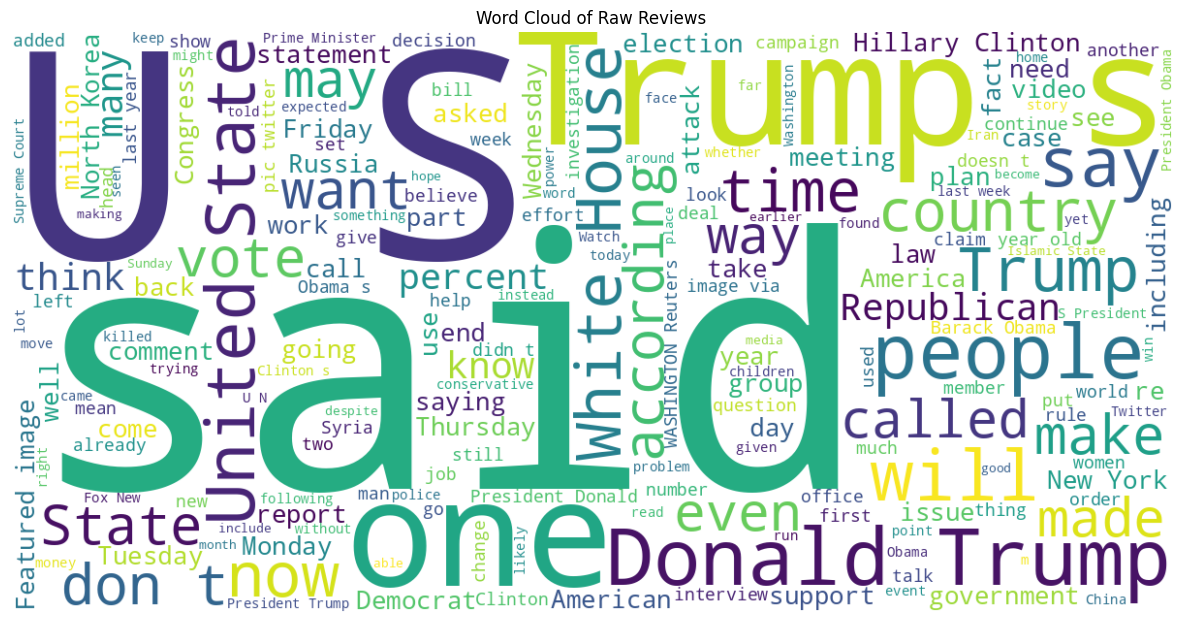

In [31]:
# creating word cloud
## combining all reviews into a single text
text = " ".join(fake_true_df["full_content"])
# creating the word cloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)
# plotting the figure
plt.figure(figsize=(15,8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Raw Reviews")
plt.show()

the word cloud describes the newsclips are about opinions , majoirly political opininons about war, trump, governce and poliotical campaignes

In [35]:
# checking value counts in each category
fake_true_df['newstype'].value_counts()

,count
newstype,
0,23481
1,21417


In [38]:
# Split the text into words
words = text.split()

# Count the frequency of each word
word_counts = Counter(words)

# Display the 20 most frequent words
word_counts.most_common(20)


[('the', 907070),
 ('to', 538754),
 ('of', 441512),
 ('and', 393995),
 ('a', 391144),
 ('in', 327394),
 ('that', 221170),
 ('on', 185433),
 ('s', 172260),
 ('for', 169435),
 ('is', 160771),
 ('with', 115402),
 ('was', 114382),
 ('Trump', 111503),
 ('he', 105988),
 ('The', 99671),
 ('as', 97859),
 ('by', 93426),
 ('said', 93162),
 ('his', 92298)]

before preprocessing commomnly appearing words are stoip words, which need to be removed.

# Preporcessing

## encoding newstypes

In [33]:
# encoding newstype
# encoding newstype as true = 1 and false  = 0
fake_true_df['newstype'] = fake_true_df['newstype'].replace({
    'fake': 0,
    'true': 1
})

/tmp/ipykernel_2520/232536204.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  fake_true_df['newstype'] = fake_true_df['newstype'].replace({


In [34]:
fake_true_df.head()

,newstype,full_content
0,0,Donald Trump Sends Out Embarrassing New Year’...
1,0,Drunk Bragging Trump Staffer Started Russian ...
2,0,Sheriff David Clarke Becomes An Internet Joke...
3,0,Trump Is So Obsessed He Even Has Obama’s Name...
4,0,Pope Francis Just Called Out Donald Trump Dur...


## missing value analysis

In [36]:
fake_true_df.isna().sum()
# no missing values

,0
newstype,0
full_content,0


## checking for duplicates

In [45]:
fake_true_df.duplicated().sum()

np.int64(0)

In [44]:
#there are 5,793 duplicate enties which need to be removed.
fake_true_df = fake_true_df.drop_duplicates()

## removing punctuations

In [48]:
# displaying the predefined punctuations in string
string.punctuation

# replacing all punctuations with empty string
fake_true_df['full_content'] = fake_true_df['full_content'].str.replace(
        f'[{string.punctuation}]',
        '',
        regex=True)
        # for finding anything matches the given pattern in string.punctuation.

/tmp/ipykernel_2520/3250223533.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fake_true_df['full_content'] = fake_true_df['full_content'].str.replace(


## lowercasing

In [49]:
# making all text columns to lowercase
fake_true_df['full_content']  = fake_true_df['full_content'] .str.lower()

/tmp/ipykernel_2520/2458530907.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fake_true_df['full_content']  = fake_true_df['full_content'] .str.lower()


## removing stop words

In [53]:
stop_words = set(stopwords.words('english'))
# Counting the number of stop words in each text column
stopword_count = fake_true_df['full_content'].apply(
    lambda text: sum(word in stop_words for word in text.split())
).sum()

print(f"full_content: {stopword_count} stop words")


full_content: 0 stop words


before stopword removal there are  6611494 stop words.

In [52]:
# Remove stopwords from full_content column
fake_true_df['full_content'] = fake_true_df['full_content'].apply(
    lambda text: " ".join(
        word for word in text.split() if word not in stop_words
    )
)


/tmp/ipykernel_2520/1725849247.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fake_true_df['full_content'] = fake_true_df['full_content'].apply(


## managing numbers

In [55]:
# getting the number of numbers in the full_content column
count = fake_true_df['full_content'].str.contains(r'\d', regex=True).sum()
print(count)

31575


numbers are not remobved because of contexual importance

## mananging special characters

In [59]:
print(fake_true_df['full_content'].str.contains(r'[^A-Za-z0-9\s]', regex=True).sum())

21432


not removig the special characters as they are of contextualm importance

## managing html tags

In [57]:
# Count HTML tags in full_content column
html_count = fake_true_df['full_content'].str.contains(r'<.*?>', regex=True).sum()

print(f"Total HTML tags found: {html_count}")

Total HTML tags found: 0


In [58]:
#no html tags are there

SyntaxError: invalid syntax (3553149855.py, line 1)

# Tokenisation

In [65]:
fake_true_df['tokens'] = fake_true_df['full_content'].str.split()
fake_true_df.head()

,newstype,full_content,tokens
0,0,donald trump sends embarrassing new year’s eve...,"[donald, trump, sends, embarrassing, new, year..."
1,0,drunk bragging trump staffer started russian c...,"[drunk, bragging, trump, staffer, started, rus..."
2,0,sheriff david clarke becomes internet joke thr...,"[sheriff, david, clarke, becomes, internet, jo..."
3,0,trump obsessed even obama’s name coded website...,"[trump, obsessed, even, obama’s, name, coded, ..."
4,0,pope francis called donald trump christmas spe...,"[pope, francis, called, donald, trump, christm..."


# Lemmatisation / stemmming

 Chosing lemmatisation as it bring the word to their irginal form, more relvant to the context.

In [66]:
# creating an object
lemmatizer = WordNetLemmatizer()

# Apply lemmatization to the tokenized text
fake_true_df['tokens_lemmatized'] = fake_true_df['tokens'].apply(
    lambda tokens: [lemmatizer.lemmatize(word) for word in tokens]
)

# Create a function that takes one input called tokens
#Considering tokens in each row; for each word in tokens, lemmatize it using the lemmatizer.

# Train- test split

In [78]:
X = fake_true_df['full_content']
y = fake_true_df['newstype']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,  # Preserve target class balance in both subsets
)

# Embedding

## TF- IDF Vectorisation

Chosing tf-idf vectorisation for sparse vector convertion as if idf,
1.  Identifies Distinctive Vocabulary
2. reduces the importance of the common words
3. no semantic understanding needed


In [79]:
# creating itfidf object
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words="english",
)

# fittign tf-idf embedding to train data
X_train_tfidf = tfidf.fit_transform(X_train)
# transforming tf_idf to test data
X_test_tfidf = tfidf.transform(X_test)


# Model building

## Logistic regression

In [80]:
# creating the object
log_reg  = LogisticRegression()
# training the model
log_reg.fit(X_train_tfidf,y_train)

# making the predictions based on X_test
y_pred_log_reg = log_reg.predict(X_test_tfidf)

In [95]:
# applying cross validation
cv_scores_logreg = cross_val_score(
    log_reg,
    X_train_tfidf,
    y_train,
    cv=5,
    scoring='recall' # chosin recall as false negative more suitable evaluation matrix
)
cv_scores_logreg # Accuracy obtained from each of the 5 cross-validation folds

array([0.99174285, 0.99174528, 0.99233491, 0.9896816 , 0.99262754])

In [96]:
cv_scores_logreg.mean() # getting average cross validation accuracy

np.float64(0.9916264369335032)

In [101]:
# evaluating the model through accuracy score
acc_log = accuracy_score(y_test, y_pred_log_reg)
prec_log = precision_score(y_test, y_pred_log_reg)
recall_log = recall_score(y_test, y_pred_log_reg)
f1_log = f1_score(y_test, y_pred_log_reg)


## Suport Vector Machine

In [82]:
svm_model = LinearSVC(
    random_state=42,
    max_iter=1000,
    C=1.0  # Regularization parameter
)

# fitting the model
svm_model.fit(X_train_tfidf, y_train)
print("Training complete!")

#Making predictions
y_pred_svm = svm_model.predict(X_test_tfidf)

Training complete!


In [97]:
# applying cross validation
cv_scores_svm = cross_val_score(
    svm_model,
    X_train_tfidf,
    y_train,
    cv=5,
    scoring='recall'
)
cv_scores_svm # Accuracy obtained from each of the 5 cross-validation folds

array([0.99587142, 0.99616745, 0.99351415, 0.99439858, 0.99616632])

In [98]:
cv_scores_svm.mean() # getting average cross validation accuracy

np.float64(0.9952235871313077)

In [103]:
# evaluating the model the recall
acc_svm= accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test,y_pred_svm)
recall_svm= recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)


## random forest

In [91]:

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,      # Number of trees
    random_state=42,
    max_depth=15,          # Maximum depth of trees
    min_samples_split=5,   # Minimum samples to split node
    min_samples_leaf=2,    # Minimum samples in leaf node
    n_jobs=-1              # Use all processors
)

# Fitting the model
rf_model.fit(X_train_tfidf, y_train)
print("Training complete!")

Training complete!


In [105]:
#Making predictions
y_pred_rf= rf_model.predict(X_test_tfidf)

In [99]:
# applying cross validation
cv_scores_rf = cross_val_score(
    rf_model,
    X_train_tfidf,
    y_train,
    cv=5,
    scoring='recall'
)
cv_scores_rf # Accuracy obtained from each of the 5 cross-validation folds

array([0.99823061, 0.99675708, 0.99793632, 0.99528302, 0.99911531])

In [100]:
cv_scores_rf.mean()

np.float64(0.9974644661506874)

In [113]:
# evaluating the model through accuracy score
acc_rf= accuracy_score(y_test, y_pred_rf)
prec_rf= precision_score(y_test,y_pred_rf)
recall_rf= recall_score(y_test, y_pred_rf)
f1_rf= f1_score(y_test, y_pred_rf)

# Evaluation of the model

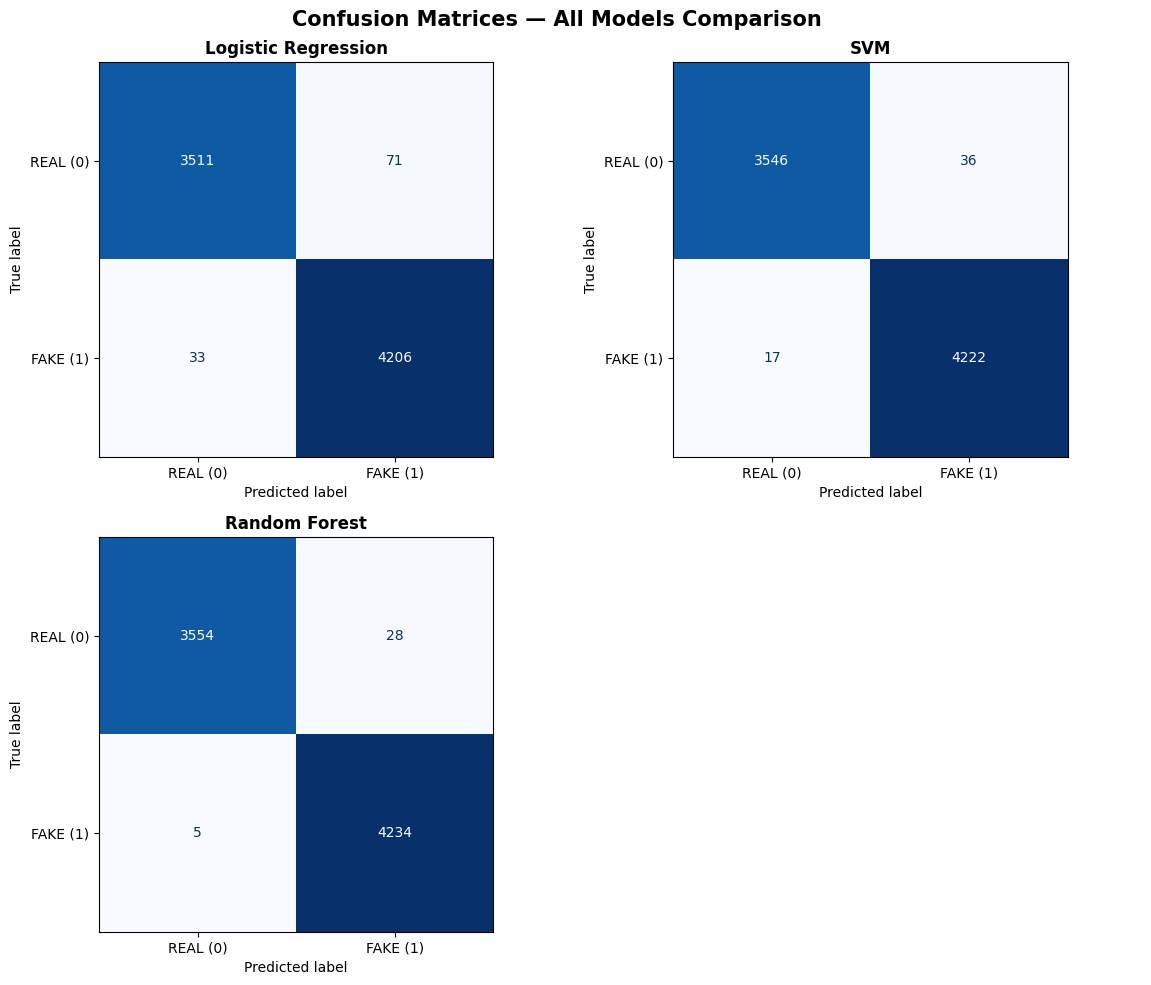

In [112]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create the vectorizer with desired parameters
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

# Fit on training data and transform
X_train_transformed = vectorizer.fit_transform(X_train)

# Transform test data using the same vectorizer
X_test_transformed = vectorizer.transform(X_test)

# Now train your models on transformed data
log_reg = LogisticRegression()
log_reg.fit(X_train_transformed, y_train)

svm_model = LinearSVC()
svm_model.fit(X_train_transformed, y_train)

rf_model = RandomForestClassifier()
rf_model.fit(X_train_transformed, y_train)

# Now create confusion matrices
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

models = {
    'Logistic Regression': log_reg,
    'SVM': svm_model,
    'Random Forest': rf_model
}

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_transformed)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["REAL (0)", "FAKE (1)"]
    )
    disp.plot(ax=axes[idx], cmap="Blues", colorbar=False, values_format="d")
    axes[idx].set_title(f"{name}", fontweight="bold")
    axes[idx].grid(False)

axes[3].axis('off')

plt.suptitle("Confusion Matrices — All Models Comparison", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

In [114]:
metrics_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM', 'Random Forest'],
    'Accuracy': [acc_log, acc_svm, acc_rf],
    'Precision': [prec_log, prec_svm, prec_rf],
    'Recall': [recall_log, recall_svm, recall_rf],
    'F1-Score': [f1_log, f1_svm, f1_rf]
})

# Round and display
display(metrics_df.round(4))

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.9893,0.9866,0.9936,0.9901
1,SVM,0.9902,0.9840,0.9981,0.9910
2,Random Forest,0.9902,0.9840,0.9981,0.9910


# Streamlit deployment

In [115]:
import os
import pickle

# Store the evaluation scores
model_scores = {
    "Logistic Regression": f1_log,
    "SVM": f1_svm,
    "Random Forest": f1_rf
}

# Select the model with the highest F1-score
best_model_name = max(model_scores, key=model_scores.get)

print("Best model:", best_model_name)
print("Best F1-score:", model_scores[best_model_name])

Best model: SVM
Best F1-score: 0.990982550649959


In [117]:
import streamlit as st
import pickle
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string

# Download required NLTK data
nltk.download('stopwords')
nltk.download('wordnet')

# Load your trained model
@st.cache_resource
def load_model():
    with open('best_model.pkl', 'rb') as file:
        model = pickle.load(file)
    return model

# Load TfidfVectorizer
@st.cache_resource
def load_vectorizer():
    with open('tfidf_vectorizer.pkl', 'rb') as file:
        vectorizer = pickle.load(file)
    return vectorizer

# Text preprocessing function
def preprocess_text(text):
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english'))

    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenize and lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    return ' '.join(tokens)

# Streamlit UI
st.set_page_config(page_title="Fake News Detector", layout="wide")
st.title("🔍 Fake News Detection System")
st.markdown("---")

# Sidebar
st.sidebar.title("About")
st.sidebar.info(
    """
    This app detects whether news articles are **FAKE** or **REAL** using Machine Learning.

    Enter the title and text of a news article to classify it.
    """
)

# Main content
col1, col2 = st.columns(2)

with col1:
    st.subheader("📝 Input Article")
    title = st.text_input("Enter the news title:")
    text = st.text_area("Enter the news article text:", height=200)

with col2:
    st.subheader("📊 Result")

    if st.button("🔎 Check Article", use_container_width=True):
        if title and text:


_IncompleteInputError: incomplete input (67715255.py, line 72)

# task *1*- analytical questions

## q1


*   The fake and true datasets are of similiar length
*   hence there is no class imbalance between the files
*   encoding newstype as true = 1 and false  = 0

## q2

* noicy

# Task 2

## Q1.

Accuracy can be missleading as it show much correct prediictions are made.but in fake news detection, false negative - identifying a a news as true while it is actually fake is misleading

## q2

random forest. as it have highest evaluation matrices and fewest false positive

##q3

Recall , as it measure howmuch false positives are made